## Notebook de analise de metricas de saida dos modelos treinados

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch -q


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import sys
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt


In [3]:
## Read files 
df1_pred = np.float32(np.load('../saida_4000-augumented/saidas/output/metricas/train/fold_0/predict_label_train_fold_0.npy', allow_pickle=True))
df1_true = np.float32(np.load('../saida_4000-augumented/saidas/output/metricas/train/fold_0/true_label_train_fold_0.npy', allow_pickle=True))

In [4]:
(df1_pred)

array([[[1., 1., 1., ..., 1., 1., 1.],
        [1., 0., 1., ..., 0., 0., 1.],
        [1., 0., 1., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       [[0., 0., 0., ..., 1., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        ...,
        [0., 1., 0., ..., 0., 1., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 1., 0.]],

       [[1., 0., 0., ..., 1., 1., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 1., 1., ..., 0., 1., 1.],
        ...,
        [1., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 1.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 1., 1., 0.],
        [0., 0., 1., ..., 1., 1., 0.],
        [1., 0., 0., ..., 0., 0.

In [5]:
def calc_loss(outputs, labels):
    criterio = nn.CrossEntropyLoss()
    acc = []
    for i in range(len(outputs)):
        #print(f'Size of output {i}: {outputs[i].shape}, Size of label {i}: {labels[i].shape}')
        loss = criterio(outputs[i], labels[i])
        acc.append(loss.item())
        #print(f'Loss for sample {i}: {loss.item()}')
    return sum(acc) / len(acc)


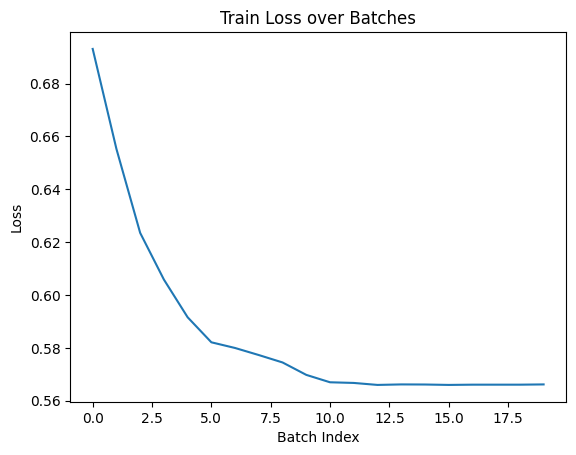

In [6]:
criterio = nn.BCEWithLogitsLoss()
total_loss = []
for i in range(len(df1_pred)):
    outputs_tensor = torch.tensor(df1_pred[i]).to(torch.float)
    labels_tensor = torch.tensor(df1_true[i]).to(torch.float)
    #print(outputs_tensor.shape, labels_tensor.shape)
    loss = criterio(outputs_tensor, labels_tensor)
    #loss = calc_loss(outputs_tensor, labels_tensor)
    total_loss.append(loss)
    #print(f'Loss for batch {i}: {loss}')
plt.plot(total_loss)
plt.title('Train Loss over Batches')
plt.xlabel('Batch Index')
plt.ylabel('Loss')
plt.show()

## Loop to print all train

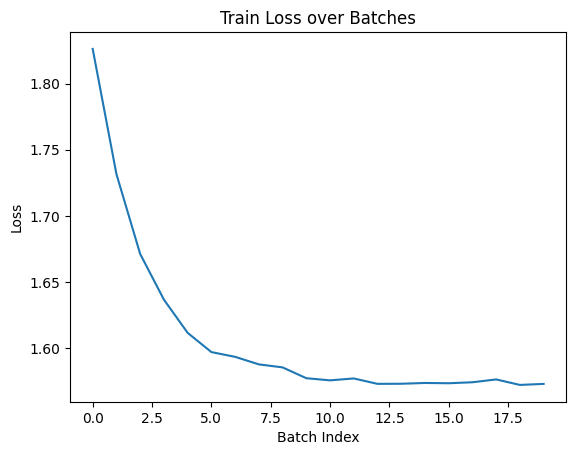

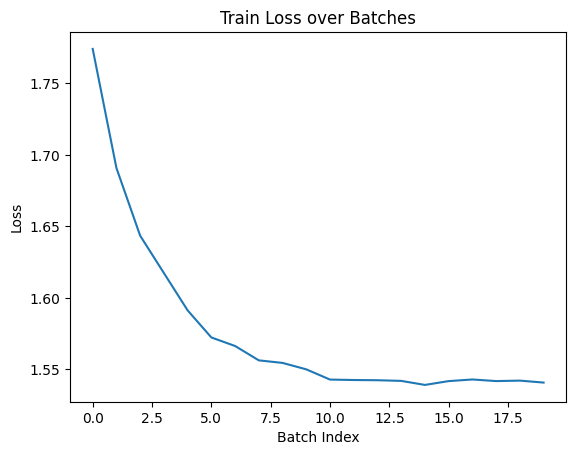

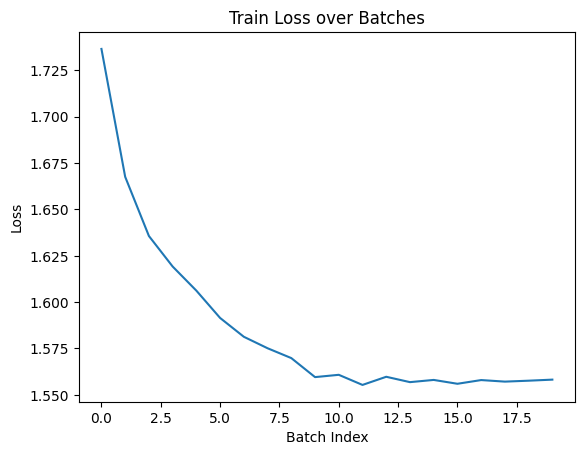

FileNotFoundError: [Errno 2] No such file or directory: '../saida_4000-augumented/saidas/output/metricas/train/fold_3/predict_label_train_fold_3.npy'

In [7]:
## Read files 
N_fold = 5

for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))
    criterio = nn.CrossEntropyLoss()
    total_loss = []
    for j in range(len(df1_pred)):
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        #print(outputs_tensor.shape, labels_tensor.shape)
        #loss = criterio(outputs_tensor, labels_tensor)
        loss = calc_loss(outputs_tensor, labels_tensor)/len(df1_pred)
        total_loss.append(loss)
        #print(f'Loss for batch {i}: {loss}')
    plt.plot(total_loss)
    plt.title('Train Loss over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.show()

In [8]:
## Calculo precisao, recall e f1 score
from sklearn.metrics import precision_score, recall_score, f1_score
for i in range(len(df1_pred)):
    outputs_tensor = torch.tensor(df1_pred[i]).to(torch.float)
    labels_tensor = torch.tensor(df1_true[i]).to(torch.float)
    
    # Convertir las predicciones a etiquetas binarias (0 o 1) usando un umbral de 0.5
    predicted_labels = (outputs_tensor > 0.5).int().numpy()
    true_labels = labels_tensor.int().numpy()
    
    precision = precision_score(true_labels, predicted_labels, average='micro')
    recall = recall_score(true_labels, predicted_labels, average='micro')
    f1 = f1_score(true_labels, predicted_labels, average='micro')
    

In [9]:
m = nn.Sigmoid()
loss = nn.BCELoss()
input = torch.randn(3, 2, requires_grad=True)
target = torch.rand(3, 2, requires_grad=False)
output = loss(m(input), target)
output

tensor(0.7810, grad_fn=<BinaryCrossEntropyBackward0>)

In [10]:
loss2 = nn.BCEWithLogitsLoss()
output2 = loss2(input, target)
output2

tensor(0.7810, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [ ]:
input

tensor([[-0.6290, -1.9906],
        [ 0.2803, -0.8853],
        [ 1.8054,  1.1920]], requires_grad=True)

In [ ]:
target

tensor([[0.1284, 0.8667],
        [0.7666, 0.0961],
        [0.5926, 0.3607]])

In [ ]:
loss2 = nn.BCEWithLogitsLoss()
output2 = loss2(input, target)
output2

tensor(0.8892, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

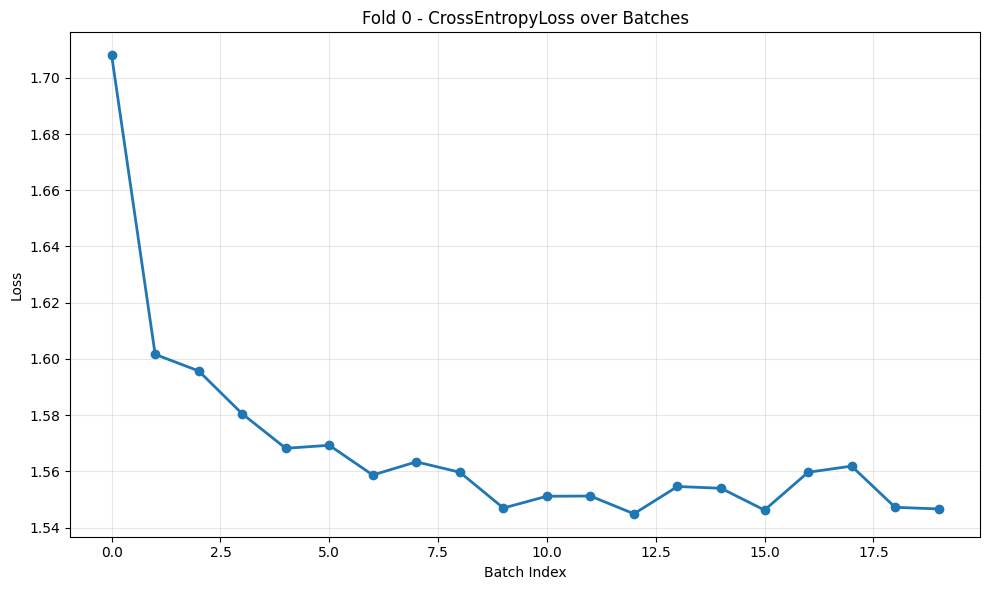

Fold 0 - Mean Loss: 1.568460, Std Loss: 0.035522


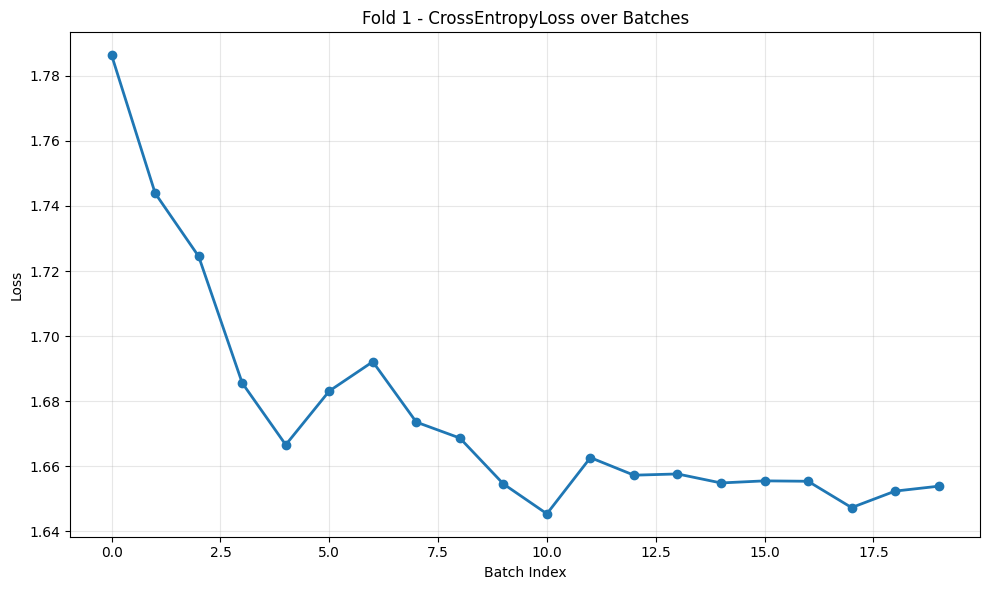

Fold 1 - Mean Loss: 1.676017, Std Loss: 0.035462


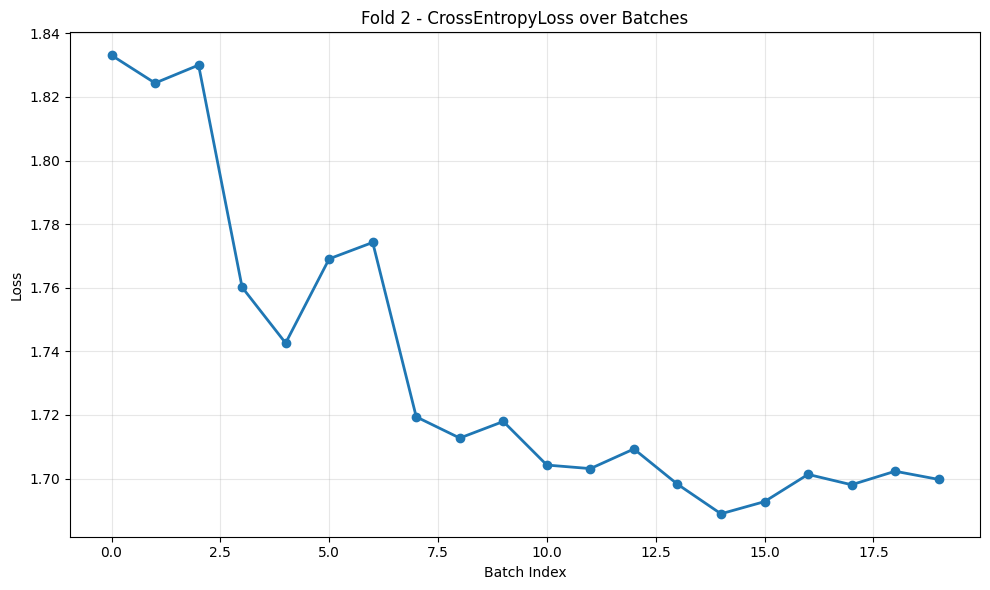

Fold 2 - Mean Loss: 1.734071, Std Loss: 0.046766


FileNotFoundError: [Errno 2] No such file or directory: '../saida_4000-augumented/saidas/output/metricas/valid/fold_3/predict_label_valid_fold_3.npy'

In [11]:
## Read files and plot metrics using CrossEntropyLoss
N_fold = 5
criterio = nn.CrossEntropyLoss()

for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
    total_loss = []
    
    for j in range(len(df1_pred)):
        # Convert predictions to tensor with correct shape for CrossEntropyLoss
        # df1_pred[j] should be (batch_size, num_classes)
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        
        # Convert labels to long integers for CrossEntropyLoss
        # df1_true[j] should be (batch_size,)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        

        # = torch.argmax(outputs_tensor, dim=1)  # Get predicted class indices
        #print(f"Batch {j}: outputs shape={outputs_tensor.shape}, labels shape={labels_tensor.shape}")
        
        # Calculate loss using CrossEntropyLoss
        loss = criterio(outputs_tensor, labels_tensor)/len(df1_pred)
        total_loss.append(loss.item())  # Extract scalar value
    
    # Plot loss over batches for this fold
    plt.figure(figsize=(10, 6))
    plt.plot(total_loss, marker='o', linestyle='-', linewidth=2)
    plt.title(f'Fold {i} - CrossEntropyLoss over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Fold {i} - Mean Loss: {np.mean(total_loss):.6f}, Std Loss: {np.std(total_loss):.6f}")


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
Batch 0: Accuracy=0.7923 / 32
tensor([[0., 1., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 1.,  ..., 0., 1., 1.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.]])
Batch 1: Accuracy=0.9037 / 32
tensor([[1., 0., 1.,  ..., 1., 1., 1.],
        [0., 1., 0.,  ..., 0., 0., 1.],
        [0., 1., 0.,  ..., 0., 1., 0.],
        ...,
        [0., 0., 1.,  ..., 0., 0., 1.],
        [0., 1., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.]])
Batch 2: Accuracy=0.9219 / 32
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 1., 1., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0.

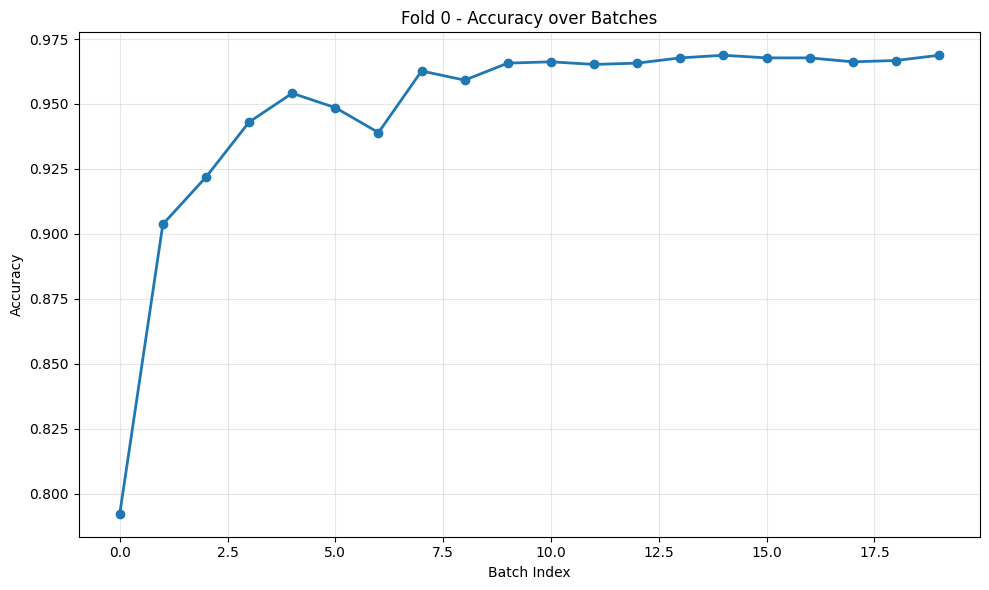

Fold 0 - Mean Accuracy: 0.948059, Std Accuracy: 0.039578
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.]])
Batch 0: Accuracy=0.7722 / 32
tensor([[0., 0., 1.,  ..., 0., 1., 0.],
        [1., 0., 1.,  ..., 1., 0., 1.],
        [1., 0., 0.,  ..., 0., 0., 1.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 1.,  ..., 1., 0., 0.]])
Batch 1: Accuracy=0.8165 / 32
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 1., 0.,  ..., 0., 0., 1.],
        ...,
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 1., 0.],
        [0., 1., 0.,  ..., 0., 0., 1.]])
Batch 2: Accuracy=0.8453 / 32
tensor([[0., 0., 0.,  ..., 1., 1., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [1.

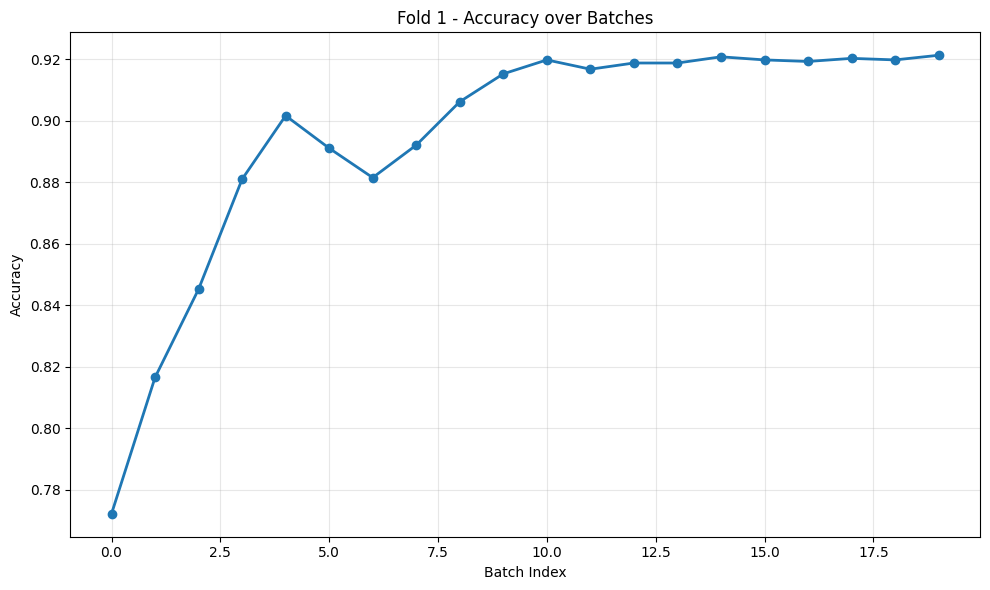

Fold 1 - Mean Accuracy: 0.894960, Std Accuracy: 0.039223
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
Batch 0: Accuracy=0.6699 / 32
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.]])
Batch 1: Accuracy=0.6815 / 32
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
Batch 2: Accuracy=0.6910 / 32
tensor([[1., 1., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [1.

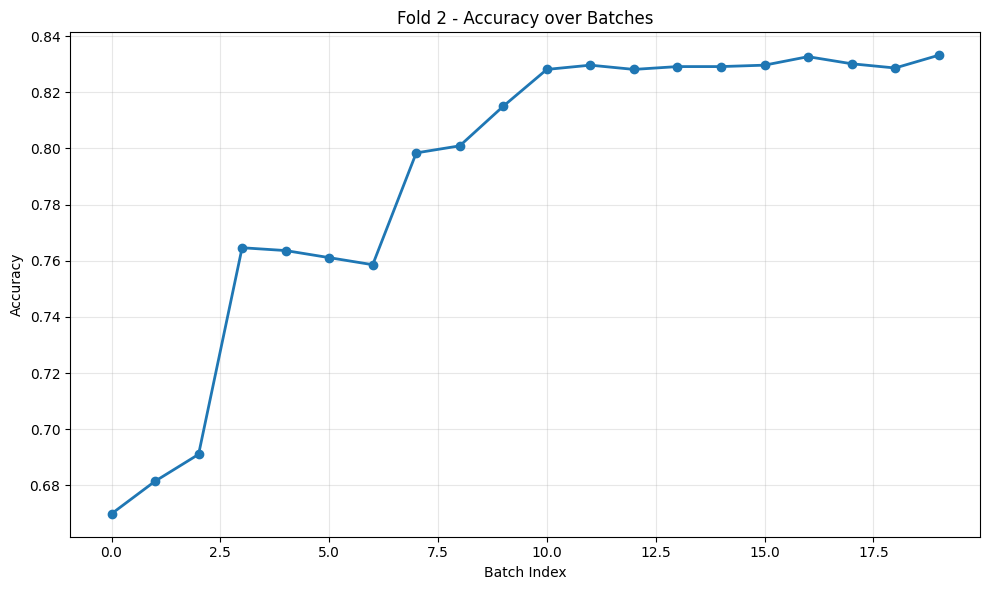

Fold 2 - Mean Accuracy: 0.790146, Std Accuracy: 0.052863


FileNotFoundError: [Errno 2] No such file or directory: '../saida_4000-augumented/saidas/output/metricas/valid/fold_3/predict_label_valid_fold_3.npy'

In [37]:
## Read files and plot metrics using CrossEntropyLoss
N_fold = 5
criterio = nn.CrossEntropyLoss()

for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
    total_loss = []
    
    for j in range(len(df1_pred)):
        # Convert predictions to tensor with correct shape for CrossEntropyLoss
        # df1_pred[j] should be (batch_size, num_classes)
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        
        # Convert labels to long integers for CrossEntropyLoss
        # df1_true[j] should be (batch_size,)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        

        # Calculo Acuracia do modelo
        # Calculate accuracy
        print(outputs_tensor)
        accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) /len(labels_tensor[-1])
        print(f"Batch {j}: Accuracy={accuracy:.4f} / {len(labels_tensor[-1])}")
        total_loss.append(accuracy)  # Store accuracy instead of loss
    # Plot loss over batches for this fold
    plt.figure(figsize=(10, 6))
    plt.plot(total_loss, marker='o', linestyle='-', linewidth=2)
    plt.title(f'Fold {i} - Accuracy over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Fold {i} - Mean Accuracy: {np.mean(total_loss):.6f}, Std Accuracy: {np.std(total_loss):.6f}")


In [ ]:
for i,j  in zip(labels_tensor, outputs_tensor):
    print(f"Label: {i}, Output: {j}")
    accuracy = torch.sum(i == j).item() / len(j)
    total_loss.append(accuracy)  # Store accuracy instead of loss


Label: tensor([1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0.]), Output: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0.])
Label: tensor([0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.]), Output: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.])
Label: tensor([1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 1., 0.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.]), Output: tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Label: tensor([0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0.,

In [22]:
accuracy

0.75